# Programming Assignment 27
## Symmetry & Skewness Analysis – Iris Dataset

**Objective:** Compute Mean, Median, and Skewness. Classify features as Symmetric, Right-Skewed, or Left-Skewed. Apply transformations (Yeo-Johnson) to fix skewness and visualize distributions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer
from sklearn.datasets import load_iris

### 1. Load Dataset

In [2]:
# Load Iris dataset
iris = load_iris(as_frame=True)
df = iris.frame.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)" : "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)" : "petal_width",
})

# Separate features (exclude target)
features = df.drop(columns=["target"])
features.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 2. Mean, Median, Skewness

In [3]:
results = []

for col in features.columns:
    mean_val = features[col].mean()
    median_val = features[col].median()
    skew_val = skew(features[col])

    if skew_val > 0.5:
        nature = "Right-Skewed"
    elif skew_val < -0.5:
        nature = "Left-Skewed"
    else:
        nature = "Symmetric"

    results.append([col, mean_val, median_val, skew_val, nature])

stats_df = pd.DataFrame(
    results,
    columns=["Feature", "Mean", "Median", "Skewness", "Distribution"]
)

print("\n--- Mean, Median & Skewness ---\n")
print(stats_df)


--- Mean, Median & Skewness ---

        Feature      Mean  Median  Skewness Distribution
0  sepal_length  5.843333    5.80  0.311753    Symmetric
1   sepal_width  3.057333    3.00  0.315767    Symmetric
2  petal_length  3.758000    4.35 -0.272128    Symmetric
3   petal_width  1.199333    1.30 -0.101934    Symmetric


### 3. Histograms (Before Transformation)

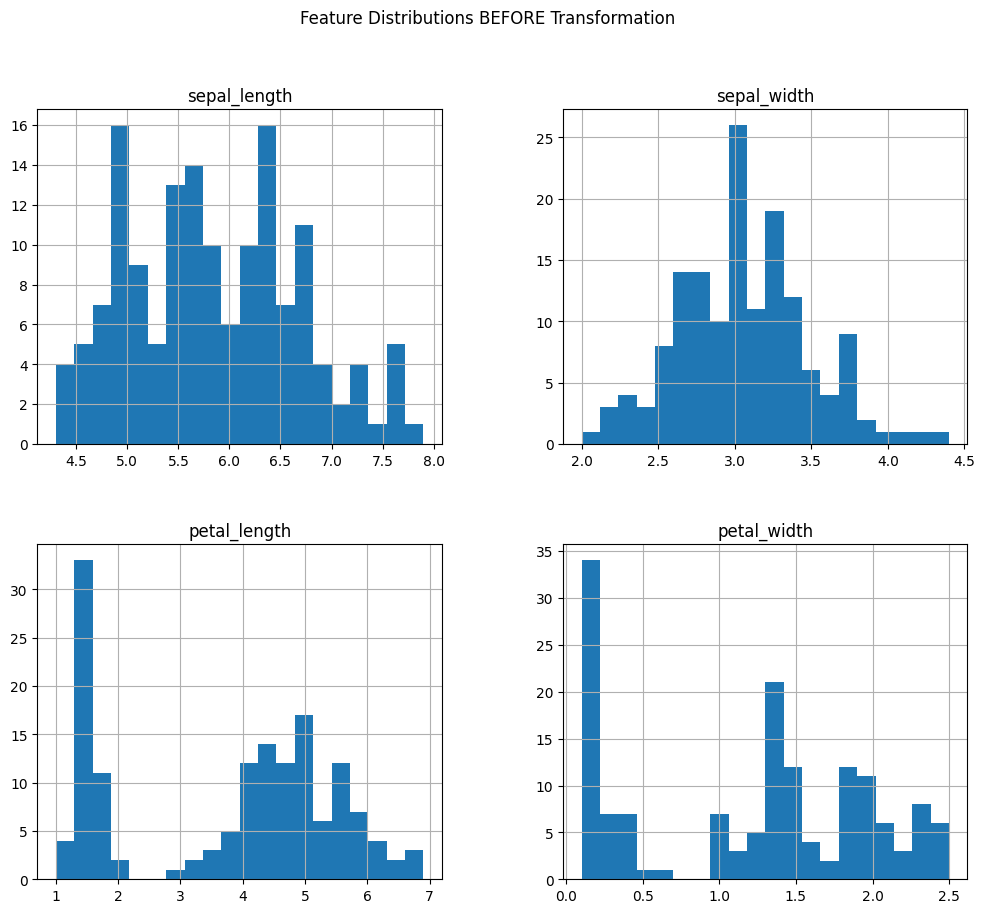

In [4]:
features.hist(bins=20, figsize=(12, 10))
plt.suptitle("Feature Distributions BEFORE Transformation")
plt.show()

### 4. Yeo-Johnson Transformation
Applying Power Transformation (Yeo-Johnson) to fix skewness.

In [5]:
pt = PowerTransformer(method="yeo-johnson")
features_transformed = pt.fit_transform(features)

trans_df = pd.DataFrame(
    features_transformed,
    columns=features.columns
)

### 5. Skewness After Transformation

In [6]:
before_skew = features.apply(skew)
after_skew = trans_df.apply(skew)

skew_compare = pd.DataFrame({
    "Before_Transformation": before_skew,
    "After_Transformation": after_skew
})

print("\n--- Skewness Comparison ---\n")
print(skew_compare)


--- Skewness Comparison ---

              Before_Transformation  After_Transformation
sepal_length               0.311753              0.009770
sepal_width                0.315767              0.000069
petal_length              -0.272128             -0.244043
petal_width               -0.101934             -0.155236


### 6. Histograms (After Transformation)

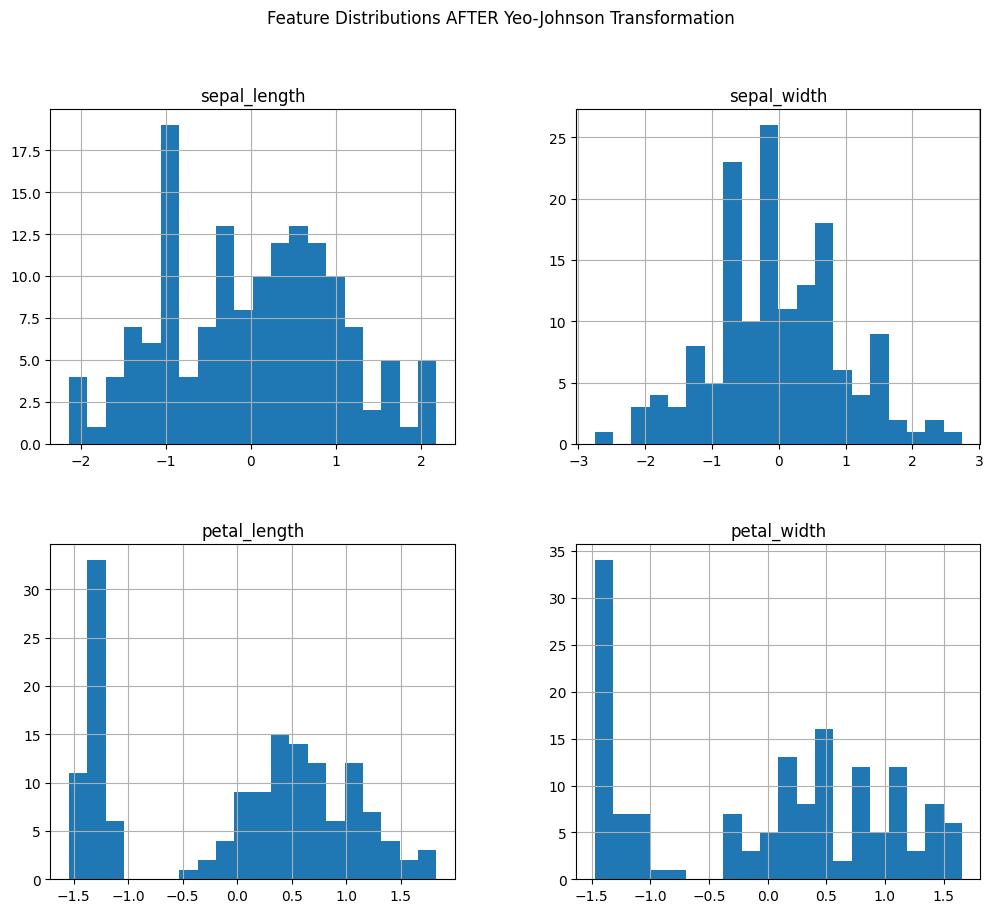

In [7]:
trans_df.hist(bins=20, figsize=(12, 10))
plt.suptitle("Feature Distributions AFTER Yeo-Johnson Transformation")
plt.show()

### 7. Bar Plot: Skewness Comparison

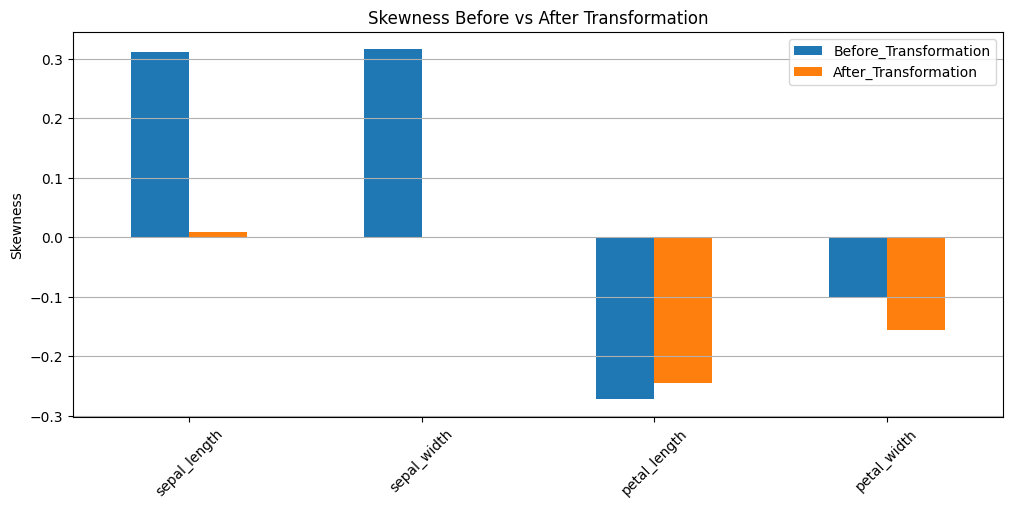

In [8]:
skew_compare.plot(kind="bar", figsize=(12, 5))
plt.title("Skewness Before vs After Transformation")
plt.ylabel("Skewness")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()